In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from invoke.completion.complete import print_task_names

from projects.Taxi_NY_Cost.research import Xtrain, ytrain

In [5]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [22]:
data = pd.read_csv('data/wine_dataset.csv')
print(data.shape)
data.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [23]:
data_red_wine = pd.read_csv('data/winequality-red.csv', delimiter=';')
print(data_red_wine.shape)
data_red_wine.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [24]:
data_white_wine = pd.read_csv('data/winequality-white.csv', delimiter=';')
print(data_white_wine.shape)
data_white_wine.head()

(4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [30]:
data['color'] = np.nan
data_white_wine['color'] = np.int8(1)
data_red_wine['color'] = np.int8(0)

In [26]:
data.drop('Id', axis=1, inplace=True)
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,NaN
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,NaN
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,NaN
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,NaN
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,NaN


In [32]:
df = pd.concat([data, data_white_wine, data_red_wine]).sample(frac=1, random_state=RANDOM_STATE).drop_duplicates().reset_index(drop=True)
print(df.shape)
df.head()

(6338, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,10.4,0.26,0.48,1.9,0.066,6.0,10.0,0.99724,3.33,0.87,10.9,6,NaN
1,5.9,0.54,0.00,0.8,0.032,12.0,82.0,0.99286,3.25,0.36,8.8,5,1.0
2,6.4,0.31,0.40,6.2,0.040,46.0,169.0,0.99530,3.15,0.46,9.3,6,1.0
3,6.9,0.34,0.74,11.2,0.069,44.0,150.0,0.99680,3.00,0.81,9.2,5,1.0
4,6.8,0.64,0.00,2.7,0.123,15.0,33.0,0.99538,3.44,0.63,11.3,6,0.0


In [28]:
df['color'].value_counts()


color
1.0    3961
0.0    1359
Name: count, dtype: int64

In [41]:
df_with_color = df[df['color'].notna()]
df_without_color = df[df['color'].isna()]

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
X_col = df_with_color.drop('color', axis=1)
y_col = df_with_color['color']

In [43]:
Xtrain_col, Xtest_col, ytrain_col, ytest_col = train_test_split(X_col, y_col, test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [52]:
params = {'C': np.arange(0.1, 1, 0.1), 'max_iter': [1000]}

gs_col = GridSearchCV(LogisticRegression(), params, cv=3, scoring='f1')
gs_col.fit(Xtrain_col, ytrain_col)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([0.1, 0....7, 0.8, 0.9]), 'max_iter': [1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed dur

In [53]:
print(gs_col.best_params_)
gs_col.best_score_

{'C': np.float64(0.9), 'max_iter': 1000}


np.float64(0.9874895872347803)

In [54]:
from sklearn.metrics import f1_score
lr_col = LogisticRegression(**gs_col.best_params_)
lr_col.fit(Xtrain_col, ytrain_col)
f1_score(ytest_col, lr_col.predict(Xtest_col))

0.9896404631322364

In [55]:
df_without_color['color'] = lr_col.predict(df_without_color.drop('color', axis=1))
df_without_color.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,10.4,0.26,0.48,1.9,0.066,6.0,10.0,0.99724,3.33,0.87,10.9,6,0.0
12,6.8,0.56,0.03,1.7,0.084,18.0,35.0,0.99680,3.44,0.63,10.0,6,0.0
15,8.8,0.48,0.41,3.3,0.092,26.0,52.0,0.99820,3.31,0.53,10.5,6,0.0
16,7.1,0.46,0.20,1.9,0.077,28.0,54.0,0.99560,3.37,0.64,10.4,6,0.0
43,10.0,0.49,0.20,11.0,0.071,13.0,50.0,1.00150,3.16,0.69,9.2,6,0.0


In [58]:
df = pd.concat([df_with_color, df_without_color]).reset_index(drop=True)
print(df['color'].isna().sum())
df.head()

0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,5.9,0.54,0.00,0.8,0.032,12.0,82.0,0.99286,3.25,0.36,8.80,5,1.0
1,6.4,0.31,0.40,6.2,0.040,46.0,169.0,0.99530,3.15,0.46,9.30,6,1.0
2,6.9,0.34,0.74,11.2,0.069,44.0,150.0,0.99680,3.00,0.81,9.20,5,1.0
3,6.8,0.64,0.00,2.7,0.123,15.0,33.0,0.99538,3.44,0.63,11.30,6,0.0
4,5.6,0.22,0.32,1.2,0.024,29.0,97.0,0.98823,3.20,0.46,13.05,7,1.0


(array([  36.,  239.,    0., 2185.,    0., 2732.,  978.,    0.,  163.,
           5.]),
 array([3. , 3.6, 4.2, 4.8, 5.4, 6. , 6.6, 7.2, 7.8, 8.4, 9. ]),
 <BarContainer object of 10 artists>)

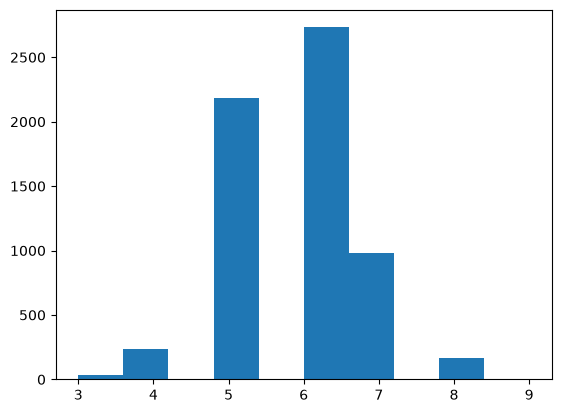

In [59]:
plt.hist(df['quality'])

<Axes: >

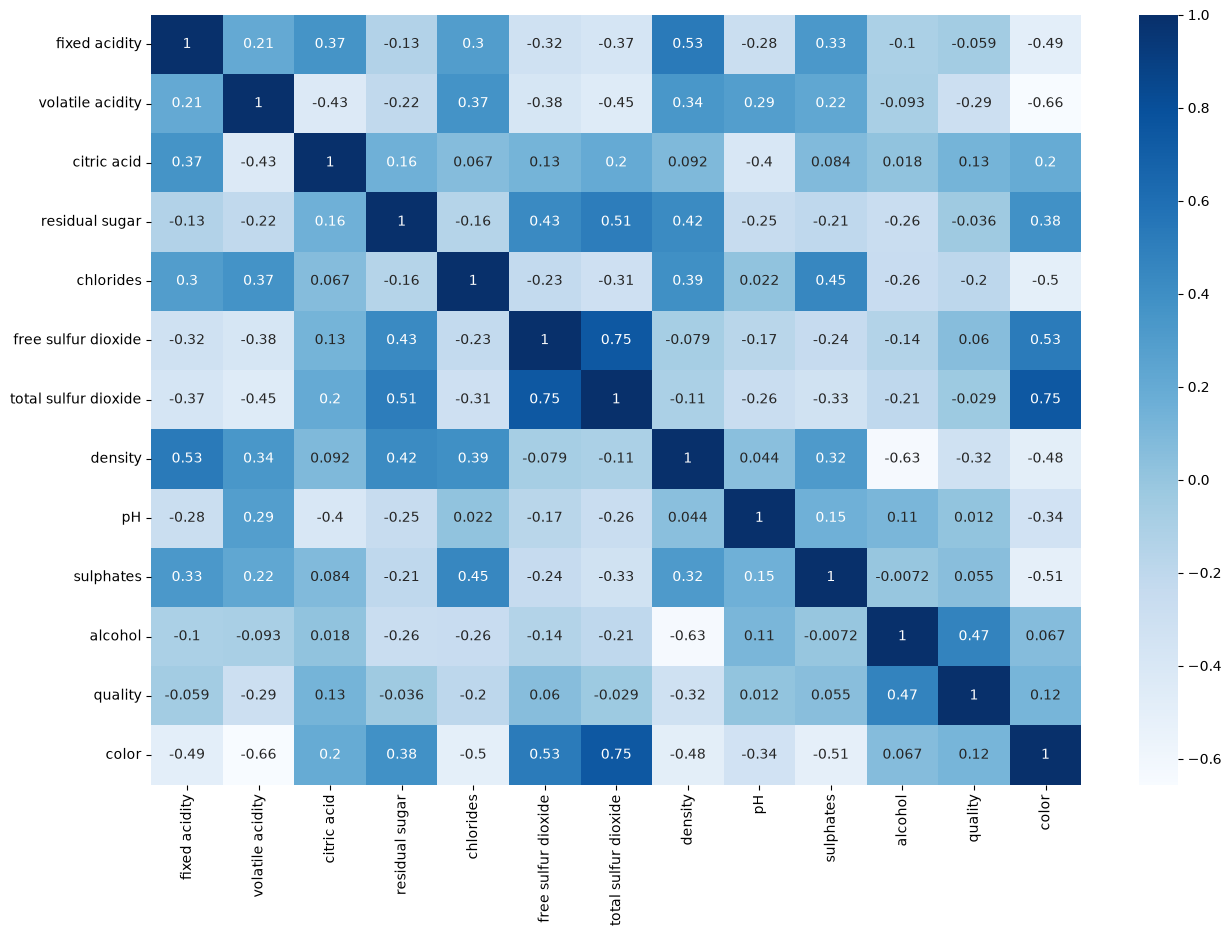

In [65]:
plt.figure(figsize=(15, 10))

sns.heatmap(df.corr(), annot=True, cmap='Blues')